In [2]:
import sys
import os
os.environ['PROJ_DATA'] = "/pscratch/sd/p/plutzner/proj_data"
import xarray as xr
import numpy as np
import importlib as imp
import pandas as pd
import matplotlib.pyplot as plt
import cftime
import pickle
import cartopy.crs as ccrs
import json
import pickle
import gzip
import scipy
import utils
from scipy import stats
from cftime import DatetimeNoLeap
from datetime import datetime
from utils.filemethods import open_data_file as open_data_file

In [12]:
# Load the two NetCDF files
ds1 = xr.open_dataset("/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_daily_total_precipitation_1940-2023.nc")
ds2 = xr.open_dataset("/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_skin_temperature_1940-2024.nc")

# Rename coordinates (modify if your names differ)
ds1 = ds1.rename({'longitude': 'lon', 'latitude': 'lat', 'valid_time': 'time'})
ds2 = ds2.rename({'longitude': 'lon', 'latitude': 'lat', 'valid_time': 'time'})


# Remove duplicates from ds2 (shouldn’t hurt to keep this)
_, index = np.unique(ds2['time'], return_index=True)
ds2 = ds2.isel(time=index)

# ds1 might still be hourly — resample to daily totals
ds1_daily = ds1.resample(time='1D').sum()

# Trim both to same time range
ds1_daily = ds1_daily.sel(time=slice("1940-01-01", "2023-12-31"))
ds2 = ds2.sel(time=slice("1940-01-01", "2023-12-31"))

# # Rename variables for clarity
# ds1_daily = ds1_daily.rename({'total_precipitation': 'precipitation'})
# ds2 = ds2.rename({'skin_temperature': 'temperature'})

# Align time coordinates explicitly
common_times = np.intersect1d(ds1_daily.time.values, ds2.time.values)
ds1_daily = ds1_daily.sel(time=common_times)
ds2 = ds2.sel(time=common_times)

# Merge
combined = xr.merge([ds1_daily, ds2])

In [13]:
# print(combined.skt)
# print(combined.tp)
# print(combined.time)
print(combined.dims)
print(combined.coords)
print(combined.var)

FrozenMappingWarningOnValuesAccess({'time': 30681, 'lat': 181, 'lon': 360})
Coordinates:
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * time     (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-12-31
<bound method DatasetAggregations.var of <xarray.Dataset> Size: 16GB
Dimensions:  (time: 30681, lat: 181, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * time     (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-12-31
Data variables:
    tp       (time, lat, lon) float32 8GB 0.003815 0.003815 ... 0.4701 0.4701
    skt      (time, lat, lon) float32 8GB ...
Attributes:
    CDI:                     Climate Data Interface version 2.0.5 (https://mp...
    Conventions:             CF-1.7
    institution:             European Cen

In [14]:
# Save the combined dataset to a new NetCDF file
combined.to_netcdf("/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_input_vars_1940-2023.nc")


combined_input_file = '/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_input_vars_1940-2023.nc'
era5_input = xr.open_dataset(combined_input_file)
era5_input.time

<xarray.DataArray 'time' (time: 30681)> Size: 245kB
array(['1940-01-01T00:00:00.000000000', '1940-01-02T00:00:00.000000000',
       '1940-01-03T00:00:00.000000000', ..., '2023-12-29T00:00:00.000000000',
       '2023-12-30T00:00:00.000000000', '2023-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-12-31
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         valid_time_bnds
    axis:           T

In [3]:
combined_input_file = '/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_input_vars_1940-2023.nc'
era5_input = xr.open_dataset(combined_input_file)

In [10]:
print(era5_input.skt[:, 80, 80].isel(time = range(40)).values)

[299.3007  299.2514  299.21414 299.18008 299.15048 299.11005 299.07858
 298.99707 298.9644  298.95767 298.91962 298.8738  298.93103 298.98105
 298.9526  298.94388 298.95764 298.95505 299.0235  298.99637 298.98083
 299.022   299.07166 299.1211  299.1614  299.18625 299.2427  299.25092
 299.2667  299.28452 299.27438 299.26547 299.442   299.63574 299.61072
 299.68323 299.65942 299.4525  299.40775 299.39633]


In [12]:
# Look for nans in the tp and skt vars:
print(np.isnan(era5_input.tp).sum())
print(np.isnan(era5_input.skt).sum())

<xarray.DataArray 'tp' ()> Size: 8B
array(0)
<xarray.DataArray 'skt' ()> Size: 8B
array(0)


In [17]:
print(era5_input.lat)
print(era5_input.lon)

<xarray.DataArray 'lat' (lat: 181)> Size: 1kB
array([ 90.,  89.,  88.,  87.,  86.,  85.,  84.,  83.,  82.,  81.,  80.,  79.,
        78.,  77.,  76.,  75.,  74.,  73.,  72.,  71.,  70.,  69.,  68.,  67.,
        66.,  65.,  64.,  63.,  62.,  61.,  60.,  59.,  58.,  57.,  56.,  55.,
        54.,  53.,  52.,  51.,  50.,  49.,  48.,  47.,  46.,  45.,  44.,  43.,
        42.,  41.,  40.,  39.,  38.,  37.,  36.,  35.,  34.,  33.,  32.,  31.,
        30.,  29.,  28.,  27.,  26.,  25.,  24.,  23.,  22.,  21.,  20.,  19.,
        18.,  17.,  16.,  15.,  14.,  13.,  12.,  11.,  10.,   9.,   8.,   7.,
         6.,   5.,   4.,   3.,   2.,   1.,   0.,  -1.,  -2.,  -3.,  -4.,  -5.,
        -6.,  -7.,  -8.,  -9., -10., -11., -12., -13., -14., -15., -16., -17.,
       -18., -19., -20., -21., -22., -23., -24., -25., -26., -27., -28., -29.,
       -30., -31., -32., -33., -34., -35., -36., -37., -38., -39., -40., -41.,
       -42., -43., -44., -45., -46., -47., -48., -49., -50., -51., -52., -53.,
      

### Add Z500 Data to Input Vars

In [2]:
P_TS_era5 = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_input_vars_1940-2023.nc')
print(f"prect, ts era5: {P_TS_era5}")

prect, ts era5: <xarray.Dataset> Size: 16GB
Dimensions:  (time: 30681, lat: 181, lon: 360)
Coordinates:
  * lon      (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
  * lat      (lat) float64 1kB 90.0 89.0 88.0 87.0 ... -87.0 -88.0 -89.0 -90.0
  * time     (time) datetime64[ns] 245kB 1940-01-01 1940-01-02 ... 2023-12-31
Data variables:
    tp       (time, lat, lon) float32 8GB ...
    skt      (time, lat, lon) float32 8GB ...
Attributes:
    CDI:                     Climate Data Interface version 2.0.5 (https://mp...
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    history:                 Wed Apr 16 14:56:07 2025: cdo mergetime merged_c...
    frequency:               day
    CDO:                     Climate Data Operators version 2.0.5 (https://mp...


In [3]:
Z500_1 = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_Z500_1940-1970.nc')
# Z500_2 = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_Z500_1971-1999.nc')
# Z500_3 = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_Z500_2000-2024.nc')
# Z500 = xr.concat([Z500_1, Z500_2, Z500_3], dim='time')

<xarray.DataArray 'z' (latitude: 721, longitude: 1440)> Size: 4MB
[1038240 values with dtype=float32]
Coordinates:
    number         int64 8B ...
    time           datetime64[ns] 8B 1940-01-09T18:00:00
    step           timedelta64[ns] 8B ...
    isobaricInhPa  float64 8B ...
  * latitude       (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude      (longitude) float64 12kB 0.0 0.25 0.5 ... 359.2 359.5 359.8
    valid_time     datetime64[ns] 8B ...
Attributes: (12/31)
    GRIB_paramId:                             129
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         isobaricInhPa
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           z
    GRIB_totalNumber:                         0
    GRIB_units:                       

<Figure size 640x480 with 0 Axes>

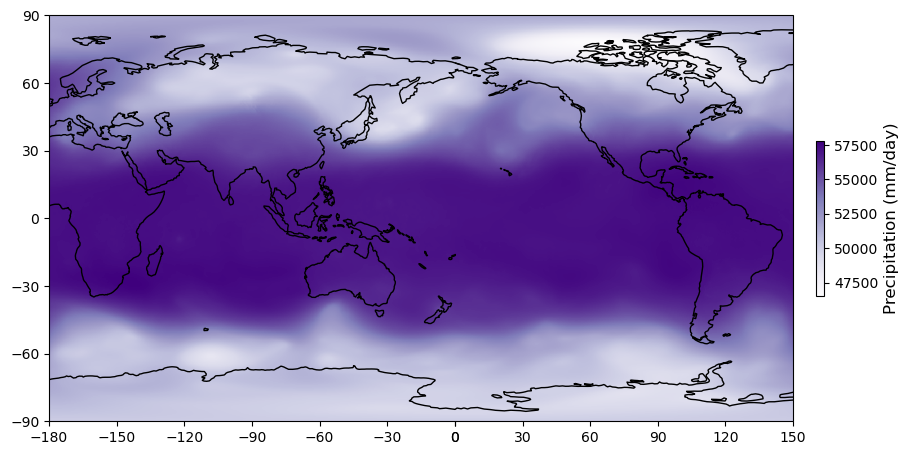

In [17]:
Z500_day = Z500_1.z.isel(time = 35)
print(Z500_day)

plt.figure()
fig, ax = plt.subplots(1, 1, figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
cf1 = ax.pcolormesh(Z500_day.longitude, Z500_day.latitude, Z500_day, cmap='Purples', transform=ccrs.PlateCarree())#, vmax=p_converted.max(), vmin=-1 * p_converted.max())
ax.coastlines()
# select only north pacific region
ax.set_extent([-180, -100, 20, 60], crs=ccrs.PlateCarree())
ax.set_xticks(np.arange(-180, 181, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())

cbar1 = fig.colorbar(cf1, cmap='PuOr', ax=ax, orientation='vertical', fraction=0.01, pad=0.03)

In [21]:
nan_mask = Z500_1.isnull()
print(sum(nan_mask))

TypeError: unsupported operand type(s) for +: 'int' and 'str'

In [ ]:
# combine ERA5 data into one dataset
era5_combined = xr.Dataset({
    'PRECT': P_TS_era5.PRECT,
    'TS': P_TS_era5.TS,
    'Z500': Z500.Z500},
    coords={
        'time': P_TS_era5.time,
        'lat': P_TS_era5.lat,
        'lon': P_TS_era5.lon
    }, 
    attrs={
        'description': 'Combined ERA5 dataset with PRECT, TS, and Z500 variables',
        'source': 'ERA5 reanalysis data'
    }
)

print(f"era5_combined: {era5_combined}")
print(f"era5_combined time: {era5_combined.time}")


# save combined dataset
era5_combined.to_netcdf('/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_combined_PRECT_TS_Z500_1940-2023.nc')

In [22]:
check_1x1 = open_data_file('/pscratch/sd/p/plutzner/E3SM/bigdata/ERA5/ERA5_1x1_Z500_1971-1999.nc')